<a href="https://colab.research.google.com/github/Ak-Space51/ml-astronomy/blob/main/week3_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 - ML in Astronomy - Week 3 . Part 2: Evaluation and Interpretation





## Step 0 - Data + model

Reproduce the Week-1 pipeline and the Part-1 `GalaxyCNN`. The data-build cells are commented out (run them once on a fresh Colab, exactly as in Part 1).

In [1]:
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [3]:
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2/images"   # adjust if your JPGs landed one folder deeper
DATA_ROOT = Path("galaxy_data")        # train/val/test subfolders get created here
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"


from google.colab import files
files.upload()  # select kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip -q install kaggle
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
!unzip -q -o galaxy-zoo-2-images.zip -d {RAW_ROOT}
!unzip -q -o {RAW_ROOT}/images_gz2.zip -d {IMAGES_DIR}
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

print("RAW_ROOT   =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT  =", DATA_ROOT)



from google.colab import drive
drive.mount('/content/drive')


def high_level(gz2_class: str):
  """Simplify codes to Spiral, elliptical or spiral-barred"""
  if not isinstance(gz2_class, str) or gz2_class == "A":
    return None #Ambiguous
  if gz2_class.startswith("E"):
    return "elliptical"
  if gz2_class.startswith("SB"):
    return "spiral_barred"
  if gz2_class.startswith("S"):
    return "spiral"
  return None

def load_labeled_table(mapping_csv, labels_csv):
  """ Join Kaggle mapping with morphology labels"""
  mapping = pd.read_csv(mapping_csv)
  labels = pd.read_csv(labels_csv)
  if("dr7objid" in labels.columns):
    labels = labels.rename(columns={"dr7objid": "objid"})
  df = mapping.merge(labels[["objid", "gz2_class"]], on= "objid", how= "inner")
  df["label"] = df["gz2_class"].map(high_level)
  df = df.dropna(subset=["label"]).reset_index(drop=True)
  return df

def _link_image(src: Path, dst: Path) -> bool:
    """Symlink if possible; otherwise copy (some Drive setups block symlinks)."""
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True


def build_split_imagefolder_layout(
    images_dir,
    df,
    out_root,
    per_class=200,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
):
    """Create out_root/{train,val,test}//*.jpg for ImageFolder."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    images_dir = Path(images_dir)
    out_root = Path(out_root)
    summary = {}

    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)

        n = len(rows)
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)
        n_test = n - n_train - n_val
        splits = {
            "train": rows.iloc[:n_train],
            "val": rows.iloc[n_train : n_train + n_val],
            "test": rows.iloc[n_train + n_val :],
        }

        summary[label] = {}
        for split_name, split_rows in splits.items():
            linked = 0
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists() and _link_image(src, dst):
                    linked += 1
            summary[label][split_name] = linked
    return summary

df = load_labeled_table(
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
)
print("Joined rows:", len(df))
print("\nLabel counts:")
print(df["label"].value_counts())

PER_CLASS = 200  # increase once the pipeline works (e.g. 2000)

summary = build_split_imagefolder_layout(
    IMAGES_DIR,
    df,
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Linked images per class and split:")
print(pd.DataFrame(summary).fillna(0).astype(int))

for split in ("train", "val", "test"):
    split_dir = DATA_ROOT / split
    classes = sorted(p.name for p in split_dir.iterdir() if p.is_dir()) if split_dir.exists() else []
    n_imgs = sum(1 for _ in split_dir.rglob("*.jpg")) if split_dir.exists() else 0
    print(f"{split:5s}: {n_imgs:4d} images  classes={classes}")



Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:40<00:00, 81.5MB/s]

unzip:  cannot find or open galaxy_raw/images_gz2.zip, galaxy_raw/images_gz2.zip.zip or galaxy_raw/images_gz2.zip.ZIP.
RAW_ROOT   = galaxy_raw
IMAGES_DIR = galaxy_raw/images_gz2/images
DATA_ROOT  = galaxy_data
Mounted at /content/drive
Joined rows: 239100

Label counts:
label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64
Linked images per class and split:
       elliptical  spiral  spiral_barred
train         140     140            140
val            30      30             30
test           30      30             30
train:  420 images  classes=['elliptical', 'spiral', 'spiral_barred']
val  :   90 images  classes=['elliptical', 'spiral', 'spiral_barred']
test :   90 images  classes=['elliptical', 'spiral', 'spiral_barred']
classes     

In [4]:
# --- Rebuild the galaxy_data/{train,val,test}/<class>/ layout if needed ---
# See week3_cnn_solution.ipynb Step 0 (or week1_data_solution.ipynb) for the
# download + build_split_imagefolder_layout(...) calls. Run those once, then:
DATA_ROOT = Path("galaxy_data")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
print("classes:", train_ds.classes, "| num_classes:", num_classes)

classes: ['elliptical', 'spiral', 'spiral_barred'] | num_classes: 3


In [5]:
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),   # (B, 16, 64, 64)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (B, 16, 32, 32)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # (B, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (B, 32, 16, 16)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                 # (B, 8192)
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),                  # (B, num_classes) logits
        )

    def forward(self, x):                                 # x: (B, 3, 64, 64)
        x = self.features(x)
        x = self.classifier(x)
        return x

model = GalaxyCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Optionally load Part-1 weights instead of re-training:
# model.load_state_dict(torch.load('galaxy_model.pth', map_location=device))
print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Step 1 - The evaluation function

Uses `model.eval()` (inference behaviour) and `torch.no_grad()` (no gradient bookkeeping). Returns average loss and accuracy on any loader.

In [18]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
    return total_loss / total, correct / total

## Step 2 - Train while tracking validation

In [19]:
num_epochs = 8
train_losses, val_losses, val_accs = [], [], []

for epoch in range(num_epochs):
  model.train()
  running = 0.0
  for inputs, targets in train_loader:
      inputs, targets = inputs.to(device), targets.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      loss.backward()
      optimizer.step()
      running += loss.item() * inputs.size(0)
  train_loss = running / len(train_loader.dataset)
  val_loss, val_acc = evaluate(model, val_loader, criterion, device)
  train_losses.append(train_loss); val_losses.append(val_loss); val_accs.append(val_acc)
  print(f"Epoch {epoch+1:2d}  train {train_loss:.3f}  val {val_loss:.3f}  val_acc {val_acc:.3f}")

Epoch  1  train 0.609  val 1.606  val_acc 0.467
Epoch  2  train 0.561  val 1.574  val_acc 0.411
Epoch  3  train 0.528  val 1.671  val_acc 0.478
Epoch  4  train 0.492  val 1.680  val_acc 0.433
Epoch  5  train 0.484  val 1.816  val_acc 0.433
Epoch  6  train 0.452  val 1.793  val_acc 0.444
Epoch  7  train 0.432  val 1.944  val_acc 0.433
Epoch  8  train 0.436  val 1.881  val_acc 0.378


## Step 3 - Plot train vs validation loss

If the two lines track together and flatten, training is healthy. If `train` keeps falling while `val` turns upward, the widening gap is overfitting - the best model is at the lowest `val` point.

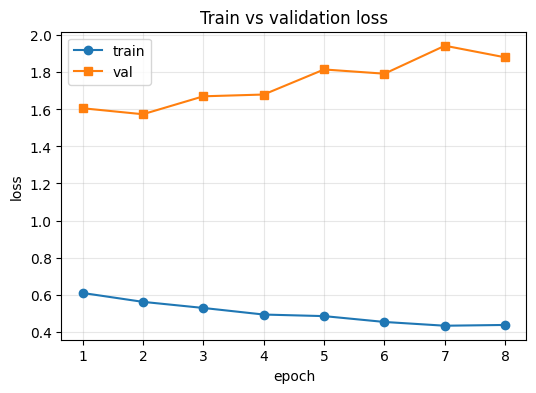

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", label="train")
plt.plot(range(1, num_epochs + 1), val_losses, marker="s", label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title("Train vs validation loss")
plt.grid(True, alpha=0.3)
plt.show()

## Step 4 - Final test accuracy vs the Week-2 baseline

In [21]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"FINAL test accuracy: {test_acc:.3f}")

week2_baseline = 0.456   # <-- replace with YOUR Week-2 KNN/LogReg test accuracy
print(f"Week-2 baseline: {week2_baseline:.3f}")
print(f"Improvement over baseline: {test_acc - week2_baseline:+.3f}")

FINAL test accuracy: 0.422
Week-2 baseline: 0.456
Improvement over baseline: -0.034


## Step 5 - Confusion matrix

Collect every prediction and true label across the test set, move them to CPU, and display a labelled matrix. Rows = true class, columns = predicted; the diagonal is correct.

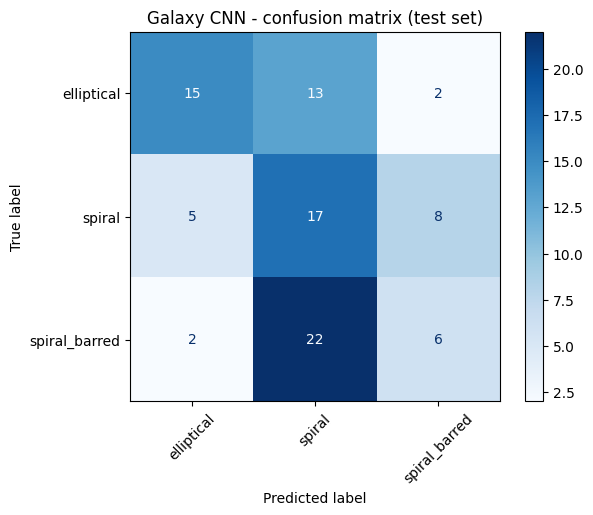

In [22]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for inputs, targets in loader:
        preds = model(inputs.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(targets)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

y_pred, y_true = collect_predictions(model, test_loader, device)
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_ds.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Galaxy CNN - confusion matrix (test set)")
plt.show()

## Step 6 - Per-class report + astrophysical reading

In [23]:
print(classification_report(y_true, y_pred, target_names=test_ds.classes))

               precision    recall  f1-score   support

   elliptical       0.68      0.50      0.58        30
       spiral       0.33      0.57      0.41        30
spiral_barred       0.38      0.20      0.26        30

     accuracy                           0.42        90
    macro avg       0.46      0.42      0.42        90
 weighted avg       0.46      0.42      0.42        90



**Reading the matrix (example).** The heaviest off-diagonal cells are typically `spiral` <-> `spiral_barred`: the bar is a subtle feature that can be faint or foreshortened (edge-on), so the two classes genuinely overlap - see density waves and bars in [`04`](../04-spiral-structure-and-star-formation.md). Smooth, bulge-dominated spirals also shade toward `elliptical`, the lenticular ambiguity from [`08`](../08-lenticulars-mergers-and-evolution.md). Much of this confusion mirrors where human classifiers also disagree, so it is partly a real physical continuum, not only a model failure.

## Step 7 - Save and reload (round-trip check)

Save the `state_dict`, rebuild a fresh `GalaxyCNN`, load the weights, and confirm identical test accuracy.

In [24]:
torch.save(model.state_dict(), "galaxy_model.pth")
print("saved galaxy_model.pth")

loaded = GalaxyCNN(num_classes=num_classes).to(device)
loaded.load_state_dict(torch.load("galaxy_model.pth", map_location=device))
loaded.eval()

_, reloaded_acc = evaluate(loaded, test_loader, criterion, device)
print(f"original test acc: {test_acc:.4f}")
print(f"reloaded test acc: {reloaded_acc:.4f}")
assert abs(reloaded_acc - test_acc) < 1e-6, "Reloaded model differs - check architecture/state_dict!"
print("Round-trip verified: weights saved and restored correctly.")

saved galaxy_model.pth
original test acc: 0.4222
reloaded test acc: 0.4222
Round-trip verified: weights saved and restored correctly.


## Step 8 (stretch) - Look at what the model got wrong

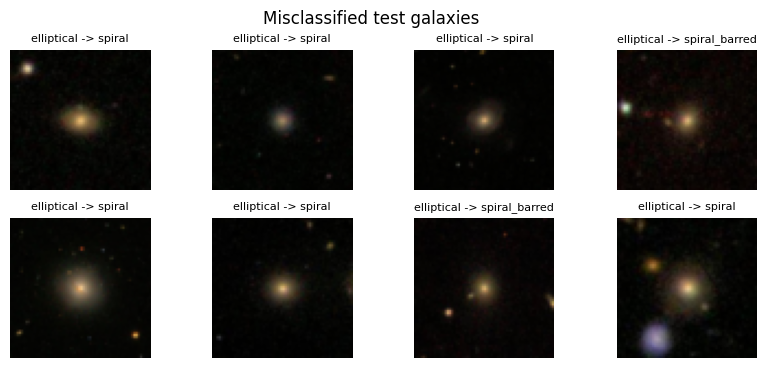

In [25]:
# Plot a few misclassified test galaxies, titled 'true -> predicted'.
model.eval()
shown = 0
plt.figure(figsize=(10, 4))
with torch.no_grad():
    for inputs, targets in test_loader:
        preds = model(inputs.to(device)).argmax(dim=1).cpu()
        for img, t, p in zip(inputs, targets, preds):
            if t != p and shown < 8:
                shown += 1
                ax = plt.subplot(2, 4, shown)
                ax.imshow((img * 0.5 + 0.5).permute(1, 2, 0).numpy())
                ax.set_title(f"{test_ds.classes[t]} -> {test_ds.classes[p]}", fontsize=8)
                ax.axis("off")
        if shown >= 8:
            break
plt.suptitle("Misclassified test galaxies")
plt.show()

## Reflection (example answers)

1. **Accuracy vs baseline.** The CNN typically lands well above the Week-2 flatten-and-classify baseline. The gap exists because convolutions preserve the spatial structure (arms, bars, bulges) that flattening destroyed - the model can actually *see* morphology.
2. **Overfitting.** If validation loss bottomed out and then rose while training loss kept falling, that is overfitting; the fixes worth trying are data augmentation (flips/rotations - natural for galaxies), more data (raise `PER_CLASS`), early stopping, or dropout.
3. **Most-confused pair.** Usually `spiral` vs `spiral_barred`. It is both a model limitation (64x64 is coarse for a faint bar) and a real ambiguity (faint/edge-on bars genuinely resemble unbarred spirals).
4. **Round-trip check.** Saving can silently go wrong (wrong path, saved before training finished, architecture mismatch). Asserting that the reloaded model reproduces the exact accuracy turns 'I think I saved it' into 'I know I can ship it'.